# Data Science Salary Analysis Dashboard

## 1. Project Introduction

This project analyzes data science job salaries using Python and Power BI.
The analysis focuses on salary patterns across job titles, experience levels,
company sizes, employment types, work years, and company locations.

An interactive Power BI dashboard was created to present the results and
allow users to explore the data using different filters.

## 2. Project Objectives

- Analyze salary trends in data science jobs.
- Compare salaries across different job titles.
- Analyze the impact of experience level on salary.
- Compare salaries across company sizes and locations.
- Analyze salary trends across different years.
- Create an interactive Power BI dashboard.

## 3. Technologies Used

- Python
- Pandas
- Matplotlib
- Power BI
- CSV Dataset

## 4. Dataset Description

The project uses the Data Science Salaries 2024 dataset.
The dataset contains approximately 14,838 records and includes information
about job titles, experience levels, employment types, salaries,
employee residence, remote work ratio, company locations, and company size.

## 5. Data Loading and Exploration

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

## 6. Data Cleaning

The dataset was checked for missing values, duplicate records,
incorrect data types, and other data quality issues before performing analysis.

In [2]:
from google.colab import files

uploaded = files.upload()

Saving DataScience_salaries_2024.csv to DataScience_salaries_2024.csv


In [6]:
import pandas as pd

df = pd.read_csv("DataScience_salaries_2024.csv")

## 7. Exploratory Data Analysis

Exploratory analysis was performed to understand salary distributions
and identify relationships between salary and different job-related factors.

In [7]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2021,MI,FT,Data Scientist,30400000,CLP,40038,CL,100,CL,L
1,2021,MI,FT,BI Data Analyst,11000000,HUF,36259,HU,50,US,L
2,2020,MI,FT,Data Scientist,11000000,HUF,35735,HU,50,HU,L
3,2021,MI,FT,ML Engineer,8500000,JPY,77364,JP,50,JP,S
4,2022,SE,FT,Lead Machine Learning Engineer,7500000,INR,95386,IN,50,IN,L


In [8]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [9]:
df.shape


(14838, 11)

In [10]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14838 entries, 0 to 14837
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           14838 non-null  int64 
 1   experience_level    14838 non-null  object
 2   employment_type     14838 non-null  object
 3   job_title           14838 non-null  object
 4   salary              14838 non-null  int64 
 5   salary_currency     14838 non-null  object
 6   salary_in_usd       14838 non-null  int64 
 7   employee_residence  14838 non-null  object
 8   remote_ratio        14838 non-null  int64 
 9   company_location    14838 non-null  object
 10  company_size        14838 non-null  object
dtypes: int64(4), object(7)
memory usage: 1.2+ MB


In [12]:
df.isnull().sum()

,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


In [13]:
df.duplicated().sum()

np.int64(5711)

In [14]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,14838.000000,1.483800e+04,14838.000000,14838.000000
mean,2023.138900,1.650227e+05,149874.718763,32.760480
std,0.700799,3.562354e+05,69009.181349,46.488278
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2023.000000,1.021000e+05,102000.000000,0.000000
50%,2023.000000,1.422000e+05,141300.000000,0.000000
75%,2024.000000,1.875000e+05,185900.000000,100.000000
max,2024.000000,3.040000e+07,800000.000000,100.000000


In [15]:
df[["salary", "salary_in_usd"]].dtypes

,0
salary,int64
salary_in_usd,int64


In [16]:
df[["experience_level", "employment_type", "remote_ratio", "company_size"]].nunique()

,0
experience_level,4
employment_type,4
remote_ratio,3
company_size,3


In [17]:
print("Experience Levels:", df["experience_level"].unique())
print("Employment Types:", df["employment_type"].unique())
print("Remote Ratios:", df["remote_ratio"].unique())
print("Company Sizes:", df["company_size"].unique())

Experience Levels: ['MI' 'SE' 'EN' 'EX']
Employment Types: ['FT' 'FL' 'CT' 'PT']
Remote Ratios: [100  50   0]
Company Sizes: ['L' 'S' 'M']


In [18]:
df["job_title"].value_counts().head(10)

,count
job_title,
Data Engineer,3162
Data Scientist,3015
Data Analyst,2189
Machine Learning Engineer,1542
Research Scientist,475
Analytics Engineer,403
Applied Scientist,383
Data Architect,369
Research Engineer,276


In [19]:
df["experience_level"].value_counts()

,count
experience_level,
SE,9696
MI,3553
EN,1148
EX,441


In [20]:
df.groupby("experience_level")["salary_in_usd"].mean().sort_values(ascending=False)

,salary_in_usd
experience_level,
EX,194730.210884
SE,163700.967100
MI,125386.553054
EN,91656.841463


In [21]:
df.groupby("company_size")["salary_in_usd"].mean().sort_values(ascending=False)

,salary_in_usd
company_size,
M,151450.535396
L,139602.460834
S,86614.569061


In [22]:
df.groupby("work_year")["salary_in_usd"].mean().sort_index()

,salary_in_usd
work_year,
2020,102250.866667
2021,99922.073394
2022,134404.072034
2023,153732.664632
2024,151510.094422


In [23]:
df.groupby("employment_type")["salary_in_usd"].mean().sort_values(ascending=False)

,salary_in_usd
employment_type,
FT,150175.764081
CT,112007.500000
PT,69608.037037
FL,50236.769231


In [24]:
df.groupby("company_location")["salary_in_usd"].mean().sort_values(ascending=False).head(10)

,salary_in_usd
company_location,
QA,300000.000000
IL,217332.000000
PR,167500.000000
US,157410.126474
NZ,147681.666667
CA,145174.987245
EG,140869.230769
SA,139999.333333
AU,130126.471698


In [25]:
df.groupby("job_title")["salary_in_usd"].mean().sort_values(ascending=False).head(10)

,salary_in_usd
job_title,
Analytics Engineering Manager,399880.000000
Data Science Tech Lead,375000.000000
Head of Machine Learning,299758.428571
Managing Director Data Science,280000.000000
AWS Data Architect,258000.000000
AI Architect,255142.357143
Cloud Data Architect,250000.000000
Director of Data Science,218775.333333
Head of Data,210013.714286


In [26]:
df.groupby("job_title")["salary_in_usd"].mean().sort_values(ascending=False).head(10)

,salary_in_usd
job_title,
Analytics Engineering Manager,399880.000000
Data Science Tech Lead,375000.000000
Head of Machine Learning,299758.428571
Managing Director Data Science,280000.000000
AWS Data Architect,258000.000000
AI Architect,255142.357143
Cloud Data Architect,250000.000000
Director of Data Science,218775.333333
Head of Data,210013.714286


In [27]:
top_jobs = (
    df.groupby("job_title")["salary_in_usd"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

top_jobs

,salary_in_usd
job_title,
Analytics Engineering Manager,399880.000000
Data Science Tech Lead,375000.000000
Head of Machine Learning,299758.428571
Managing Director Data Science,280000.000000
AWS Data Architect,258000.000000
AI Architect,255142.357143
Cloud Data Architect,250000.000000
Director of Data Science,218775.333333
Head of Data,210013.714286


In [30]:
import pandas as pd
import matplotlib.pyplot as plt

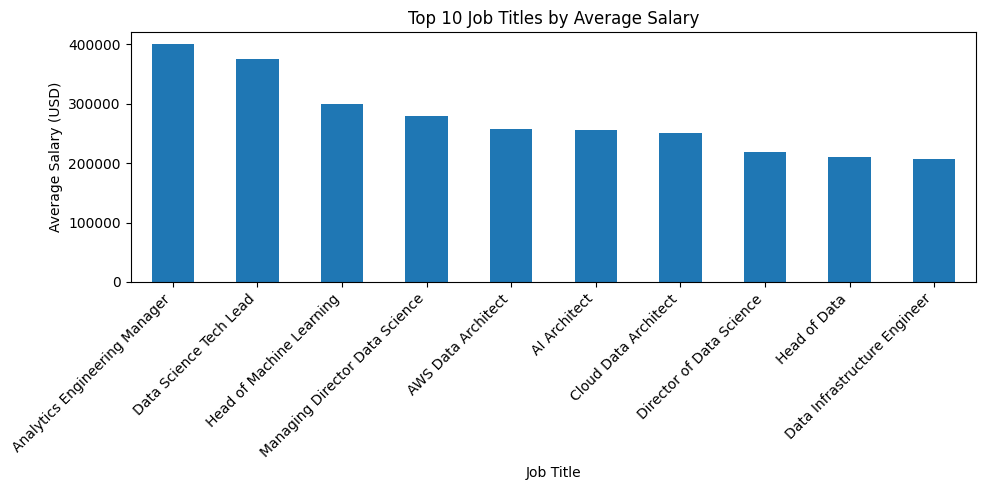

In [31]:
top_jobs.plot(kind="bar", figsize=(10, 5))

plt.title("Top 10 Job Titles by Average Salary")
plt.xlabel("Job Title")
plt.ylabel("Average Salary (USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

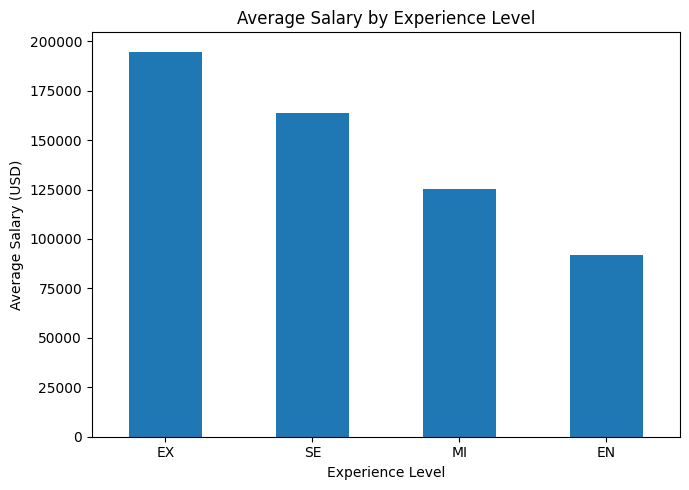

In [33]:
experience_salary = df.groupby("experience_level")["salary_in_usd"].mean().sort_values(ascending=False)

experience_salary.plot(kind="bar", figsize=(7,5))
plt.title("Average Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Average Salary (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

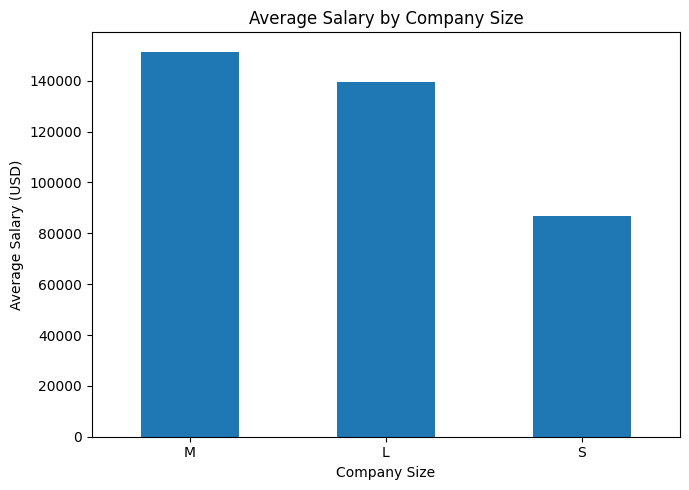

In [34]:
company_salary = df.groupby("company_size")["salary_in_usd"].mean().sort_values(ascending=False)

company_salary.plot(kind="bar", figsize=(7,5))
plt.title("Average Salary by Company Size")
plt.xlabel("Company Size")
plt.ylabel("Average Salary (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

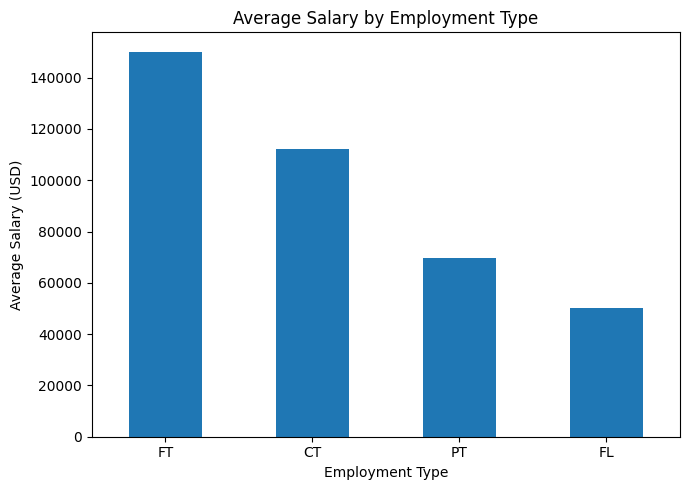

In [35]:
employment_salary = df.groupby("employment_type")["salary_in_usd"].mean().sort_values(ascending=False)

employment_salary.plot(kind="bar", figsize=(7,5))
plt.title("Average Salary by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Average Salary (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

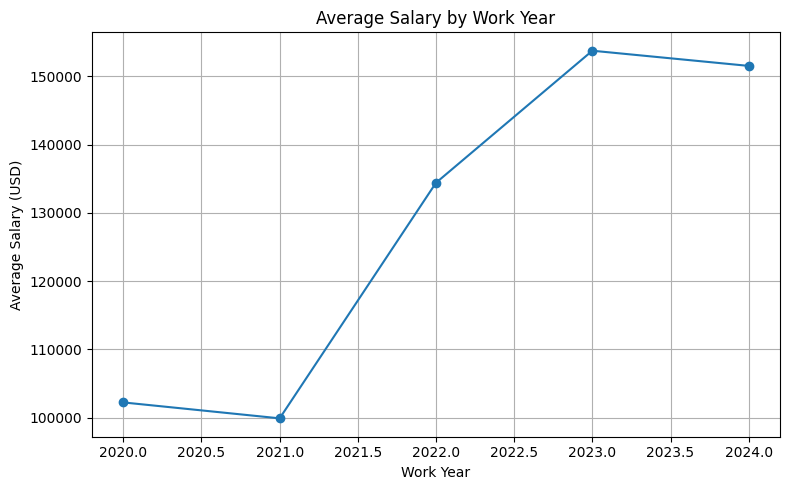

In [36]:
year_salary = df.groupby("work_year")["salary_in_usd"].mean().sort_index()

year_salary.plot(kind="line", marker="o", figsize=(8,5))
plt.title("Average Salary by Work Year")
plt.xlabel("Work Year")
plt.ylabel("Average Salary (USD)")
plt.grid(True)
plt.tight_layout()
plt.show()

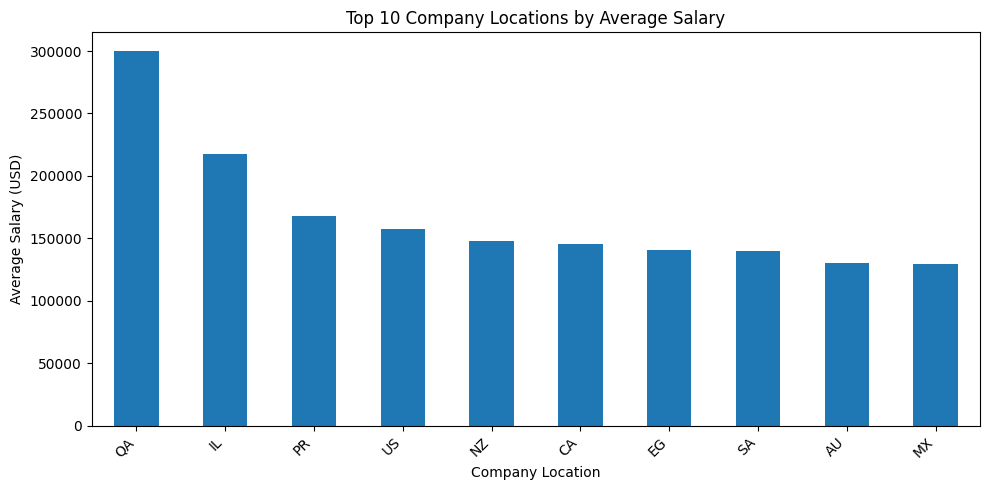

In [37]:
location_salary = df.groupby("company_location")["salary_in_usd"].mean().sort_values(ascending=False).head(10)

location_salary.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Company Locations by Average Salary")
plt.xlabel("Company Location")
plt.ylabel("Average Salary (USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 8. Data Visualizations

Different visualizations were created to analyze salary based on
job title, experience level, company size, employment type,
work year, and company location.

## 9. Key Insights

The analysis helped identify important salary patterns based on
experience, job role, company size, employment type, year, and location.

### Key Insights

- Salary varies significantly across different data science job roles.
- Higher experience levels generally have higher average salaries.
- Average salary differs across small, medium, and large companies.
- Salary levels changed across the years from 2020 to 2024.
- Employment type can influence salary levels.
- Company location is an important factor in salary differences.
- Some specialized and senior-level roles have substantially higher salaries.

## 10. Power BI Dashboard

An interactive Power BI dashboard was created using KPI cards,
charts, and slicers to allow users to explore salary trends dynamically.


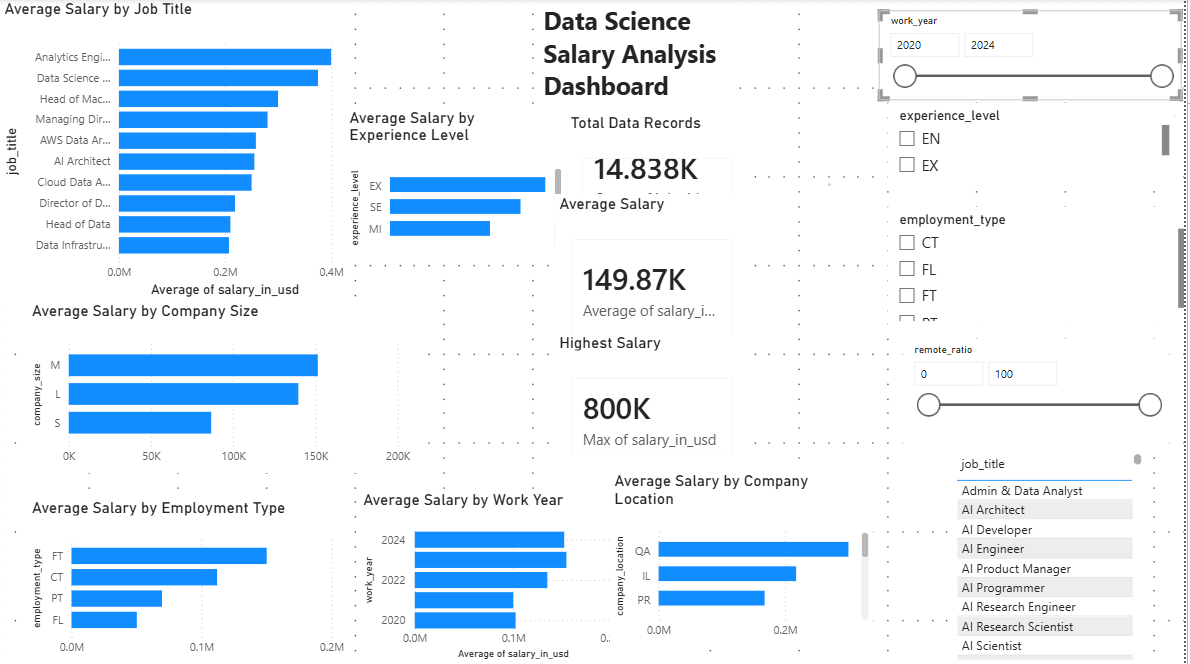

## Conclusion

This project analyzed data science job salary data using Python, Pandas,
and Power BI. The analysis explored salary differences based on job role,
experience level, company size, employment type, work year, and company
location.

Python was used for data analysis and visualization, while Power BI was
used to create an interactive dashboard. The project demonstrates how
data analysis and visualization can be used to generate meaningful
insights from real-world salary data.